# data

In [6]:
import numpy as np
import pandas as pd
import json
import matplotlib.pyplot as plt
from pathlib import Path
import calendar

START = "2016-06-01"
END   = "2025-06-30"

# START = "2024-09-01"
# END = "2025-06-30"

In [7]:
import os
import glob
import pandas as pd

PORT_DIR = "../responses_portfolios"

def _find_date_col(df: pd.DataFrame) -> str:
    for c in ["date_key", "Date", "date", "ym"]:
        if c in df.columns:
            return c
    # fallback: first unnamed index column
    if len(df.columns) > 0 and str(df.columns[0]).lower().startswith("unnamed"):
        df = df.rename(columns={df.columns[0]: "date_key"})
        return "date_key"
    raise ValueError(f"Aucune colonne de date trouvée. Colonnes: {list(df.columns)}")

def _read_and_standardize(path: str) -> pd.DataFrame:
    df = pd.read_csv(path)
    date_col = _find_date_col(df)

    # Standardize to 'date_key' as datetime
    if date_col == "ym":
        # 'YYYY-MM' -> month start
        df["date_key"] = pd.to_datetime(df["ym"].astype(str) + "-01", errors="coerce")
    else:
        df["date_key"] = pd.to_datetime(df[date_col], errors="coerce")

    # drop original date cols (except date_key)
    drop_cols = [c for c in ["Date", "date", "ym"] if c in df.columns and c != "date_key"]
    df = df.drop(columns=drop_cols, errors="ignore")

    # keep only rows with date
    df = df.dropna(subset=["date_key"]).copy()
    return df

def combine_monthly_portfolios(
    pattern: str,
    out_path: str,
) -> pd.DataFrame:
    files = sorted(glob.glob(os.path.join(PORT_DIR, pattern)))
    if not files:
        raise FileNotFoundError(f"Aucun fichier trouvé avec le pattern: {PORT_DIR}/{pattern}")

    dfs = []
    for f in files:
        df = _read_and_standardize(f)
        df["source_file"] = os.path.basename(f)  # pratique pour debug
        dfs.append(df)

    out = pd.concat(dfs, ignore_index=True)

    # sort & drop duplicates by date (keep last)
    out = out.sort_values("date_key")
    out = out.drop_duplicates(subset=["date_key"], keep="last").reset_index(drop=True)

    # save combined
    os.makedirs(os.path.dirname(out_path), exist_ok=True)
    out.to_csv(out_path, index=False)
    return out

# ---- Build combined baseline files ----
eq_combined = combine_monthly_portfolios(
    pattern="equal_weighted_portfolio*.csv",
    out_path=os.path.join(PORT_DIR, "equal_weighted_portfolio.csv"),
)

opt_combined = combine_monthly_portfolios(
    pattern="optimized_portfolio*.csv",
    out_path=os.path.join(PORT_DIR, "optimized_portfolio.csv"),
)

print("Baselines combinés :")
print(" -", os.path.join(PORT_DIR, "equal_weighted_portfolio.csv"), "(", len(eq_combined), "rows )")
print(" -", os.path.join(PORT_DIR, "optimized_portfolio.csv"), "(", len(opt_combined), "rows )")
display(eq_combined.head())
display(opt_combined.head())


Baselines combinés :
 - ../responses_portfolios\equal_weighted_portfolio.csv ( 125 rows )
 - ../responses_portfolios\optimized_portfolio.csv ( 125 rows )


,Portfolio_Return,date_key,source_file
0,0.052302,2015-02-01,equal_weighted_portfolio_2015-01-01_2015-01-31...
1,-0.026137,2015-03-01,equal_weighted_portfolio_2015-02-01_2015-02-28...
2,0.031671,2015-04-01,equal_weighted_portfolio_2015-03-01_2015-03-31...
3,0.006735,2015-05-01,equal_weighted_portfolio_2015-04-01_2015-04-30...
4,-0.025121,2015-06-01,equal_weighted_portfolio_2015-05-01_2015-05-31...


,Portfolio_Return,date_key,source_file
0,0.052302,2015-02-01,optimized_portfolio_2015-01-01_2015-01-31.csv
1,-0.026137,2015-03-01,optimized_portfolio_2015-02-01_2015-02-28.csv
2,0.031671,2015-04-01,optimized_portfolio_2015-03-01_2015-03-31.csv
3,0.006735,2015-05-01,optimized_portfolio_2015-04-01_2015-04-30.csv
4,-0.025121,2015-06-01,optimized_portfolio_2015-05-01_2015-05-31.csv


In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

"""
Baselines portfolio returns (generated by baselines.py)
Expected files:
  - responses_portfolios/equal_weighted_portfolio.csv
  - responses_portfolios/optimized_portfolio.csv
"""
equal_weighted_portfolio_returns = pd.read_csv('../responses_portfolios/equal_weighted_portfolio.csv')
optimized_portfolio_returns      = pd.read_csv('../responses_portfolios/optimized_portfolio.csv')

equal_weighted_portfolio_returns.head()
optimized_portfolio_returns.tail()


,Portfolio_Return,date_key,source_file
120,-0.023477,2025-02-01,optimized_portfolio.csv
121,-0.101440,2025-03-01,optimized_portfolio.csv
122,-0.007443,2025-04-01,optimized_portfolio.csv
123,0.039691,2025-05-01,optimized_portfolio.csv
124,0.005713,2025-06-01,optimized_portfolio_2025-05-01_2025-05-31.csv


In [10]:
"""
GPT monthly portfolio weights (Black-Litterman output from evaluate_multiple_updated.py)
"""
import pandas as pd
import numpy as np

tau = 0.025

weights_path = f"../results/gpt_black_litterman_market_implied_weights_tau_{tau}.csv"
gpt_weights_df = pd.read_csv(weights_path)

# detect date column
if "Date" in gpt_weights_df.columns:
    date_col = "Date"
elif "date_key" in gpt_weights_df.columns:
    date_col = "date_key"
else:
    date_col = gpt_weights_df.columns[0]

gpt_weights_df[date_col] = pd.to_datetime(gpt_weights_df[date_col], errors="coerce")
gpt_weights_df = gpt_weights_df.dropna(subset=[date_col]).set_index(date_col).sort_index()

# transpose for plotting: rows=tickers, columns=dates
gpt_results = gpt_weights_df.T


In [12]:
"""
Gemma3 1B monthly portfolio weights (Black-Litterman output from evaluate_multiple.py)
"""
import pandas as pd

tau = 0.025

weights_path = f"../results/gemma3_black_litterman_market_implied_weights_tau_{tau}.csv"
gemma_weights_df = pd.read_csv(weights_path)

# detect date column
if "Date" in gemma_weights_df.columns:
    date_col = "Date"
elif "date_key" in gemma_weights_df.columns:
    date_col = "date_key"
else:
    date_col = gemma_weights_df.columns[0]

gemma_weights_df[date_col] = pd.to_datetime(gemma_weights_df[date_col], errors="coerce")
gemma_weights_df = gemma_weights_df.dropna(subset=[date_col]).set_index(date_col).sort_index()

# transpose for plotting: rows=tickers, columns=dates
gemma_results = gemma_weights_df.T


In [14]:
"""
Qwen2.5 1.5B monthly portfolio weights (Black-Litterman output)
"""
import glob
import pandas as pd
import numpy as np

tau = 0.025

# Try a couple of common naming conventions
patterns = [
    f"../results/qwen_black_litterman_market_implied_weights_tau_{tau}.csv",
    f"../results/qwen_black_litterman_market_implied_weights_tau_{tau}_*.csv",
]

candidates = []
for pat in patterns:
    candidates += sorted(glob.glob(pat))

# If both exact + wildcard matched, keep unique
candidates = sorted(set(candidates))
if not candidates:
    raise FileNotFoundError(
        "Could not find Qwen weights CSV in results/. Tried patterns:"
        + "".join(f"- {p}" for p in patterns)
        + "Generate it first (e.g., evaluate_multiple / calculate_llm_returns)."
    )

qwen_weights_path = candidates[-1]
print("Using:", qwen_weights_path)
qwen_weights_df = pd.read_csv(qwen_weights_path)

# detect date column
if "Date" in qwen_weights_df.columns:
    date_col = "Date"
elif "date_key" in qwen_weights_df.columns:
    date_col = "date_key"
else:
    date_col = qwen_weights_df.columns[0]

qwen_weights_df[date_col] = pd.to_datetime(qwen_weights_df[date_col], errors="coerce")
qwen_weights_df = qwen_weights_df.dropna(subset=[date_col]).set_index(date_col).sort_index()

# transpose for plotting: rows=tickers, columns=dates
qwen_results = qwen_weights_df.T
qwen_results.head()


Using: ../results/qwen_black_litterman_market_implied_weights_tau_0.025.csv


Date,2015-01-01,2015-02-01,2015-03-01,2015-04-01,2015-05-01,2015-06-01,2015-07-01,2015-08-01,2015-09-01,2015-10-01,...,2024-08-01,2024-09-01,2024-10-01,2024-11-01,2024-12-01,2025-01-01,2025-02-01,2025-03-01,2025-04-01,2025-05-01
AAPL,0.049433,0.000000e+00,0.0,4.129736e-18,0.0,0.000000e+00,0.000000e+00,1.476336e-17,1.571838e-17,1.338576e-18,...,9.227072e-18,3.469447e-18,0.000000e+00,9.959033e-18,1.551584e-18,9.063677e-18,0.000000,1.537288e-18,0.000000,1.284088e-17
ABBV,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,3.881005e-02,1.354867e-01,1.467887e-01,1.245817e-02,0.000000e+00,0.000000e+00,0.403215,2.308786e-01,0.258525,9.344430e-02
ADBE,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
AMZN,0.047513,2.828940e-17,0.0,0.000000e+00,0.0,1.209236e-17,3.943886e-18,0.000000e+00,1.221418e-17,1.065472e-17,...,0.000000e+00,7.472514e-19,0.000000e+00,7.422214e-19,NaN,NaN,NaN,NaN,NaN,NaN
AVGO,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,9.730669e-18,2.744334e-18,1.469860e-17,0.000000e+00,5.780535e-03,1.172649e-02,0.000000,4.331145e-19,0.000000,1.409992e-01


In [16]:
"""
None / no-views monthly portfolio weights (Black-Litterman output)

This is the Black-Litterman portfolio without LLM views. It uses only the
market-implied equilibrium prior, so it is useful as the direct comparison
point for the LLM-tilted BL portfolios.
"""
import glob
import pandas as pd

tau = 0.025

patterns = [
    # New market-implied naming convention
    f"../results/none_black_litterman_market_implied_weights_tau_{tau}.csv",
    f"../results/None_black_litterman_market_implied_weights_tau_{tau}.csv",
    f"../results/none_black_litterman_market_implied_weights_tau_{tau}_*.csv",
    f"../results/None_black_litterman_market_implied_weights_tau_{tau}_*.csv",

    # Older/fallback naming conventions
    f"../results/none_black_litterman_weights_tau_{tau}.csv",
    f"../results/None_black_litterman_weights_tau_{tau}.csv",
    f"../results/none_black_litterman_weights_tau_{tau}_*.csv",
    f"../results/None_black_litterman_weights_tau_{tau}_*.csv",
]

candidates = []
for pat in patterns:
    candidates += sorted(glob.glob(pat))

candidates = sorted(set(candidates))
if not candidates:
    raise FileNotFoundError(
        "Could not find None/no-views weights CSV in results/. Tried patterns:- "
        + "-".join(patterns)
    )

none_weights_path = candidates[-1]
print(f"Using None/no-views weights file: {none_weights_path}")

none_weights_df = pd.read_csv(none_weights_path)

# detect date column
if "Date" in none_weights_df.columns:
    date_col = "Date"
elif "date_key" in none_weights_df.columns:
    date_col = "date_key"
else:
    date_col = none_weights_df.columns[0]

none_weights_df[date_col] = pd.to_datetime(none_weights_df[date_col], errors="coerce")
none_weights_df = none_weights_df.dropna(subset=[date_col]).set_index(date_col).sort_index()

# transpose for plotting: rows=tickers, columns=dates
none_results = none_weights_df.T
none_results.head()


Using None/no-views weights file: ../results/none_black_litterman_market_implied_weights_tau_0.025.csv


Date,2015-01-01,2015-02-01,2015-03-01,2015-04-01,2015-05-01,2015-06-01,2015-07-01,2015-08-01,2015-09-01,2015-10-01,...,2024-09-01,2024-10-01,2024-11-01,2024-12-01,2025-01-01,2025-02-01,2025-03-01,2025-04-01,2025-05-01,2025-06-01
AAPL,0.135539,0.140017,0.150886,0.146260,0.136728,0.141652,0.138745,0.134742,0.130773,0.126745,...,0.152509,0.150413,0.146430,0.144803,0.186916,0.170242,0.172986,0.170371,0.163628,0.144848
ABBV,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.015189,0.014896,0.015442,0.013048,0.015506,0.015589,0.017571,0.018924,0.017691,0.015873
ADBE,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
AMZN,0.030374,0.033780,0.035677,0.034992,0.037240,0.037716,0.039389,0.048845,0.048784,0.048375,...,0.082062,0.083637,0.084046,0.088234,NaN,NaN,NaN,NaN,NaN,NaN
AVGO,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.033310,0.034406,0.034001,0.030657,0.053646,0.049753,0.044512,0.040195,0.046388,0.054958


In [18]:
"""
Llama3.2 monthly portfolio weights (Black-Litterman output)
"""
import glob
import pandas as pd
import numpy as np

tau = 0.025

# Try a couple of common naming conventions
patterns = [
    f"../results/llama_black_litterman_market_implied_weights_tau_{tau}.csv",
    f"../results/llama_black_litterman_market_implied_weights_tau_{tau}_*.csv",
]

candidates = []
for pat in patterns:
    candidates += sorted(glob.glob(pat))

# If both exact + wildcard matched, keep unique
candidates = sorted(set(candidates))
if not candidates:
    raise FileNotFoundError(
        "Could not find Llama weights CSV in results/. Tried patterns:"
        + "".join(f"- {p}" for p in patterns)
        + "Generate it first (e.g., evaluate_multiple / calculate_llm_returns)."
    )

llama_weights_path = candidates[-1]
print("Using:", llama_weights_path)
llama_weights_df = pd.read_csv(llama_weights_path)

# detect date column
if "Date" in llama_weights_df.columns:
    date_col = "Date"
elif "date_key" in llama_weights_df.columns:
    date_col = "date_key"
else:
    date_col = llama_weights_df.columns[0]

llama_weights_df[date_col] = pd.to_datetime(llama_weights_df[date_col], errors="coerce")
llama_weights_df = llama_weights_df.dropna(subset=[date_col]).set_index(date_col).sort_index()

# transpose for plotting: rows=tickers, columns=dates
llama_results = llama_weights_df.T
llama_results.head()


Using: ../results/llama_black_litterman_market_implied_weights_tau_0.025.csv


Date,2015-01-01,2015-02-01,2015-03-01,2015-04-01,2015-05-01,2015-06-01,2015-07-01,2015-08-01,2015-09-01,2015-10-01,...,2024-08-01,2024-09-01,2024-10-01,2024-11-01,2024-12-01,2025-01-01,2025-02-01,2025-03-01,2025-04-01,2025-05-01
AAPL,0.064516,1.667953e-17,0.000000e+00,3.188081e-18,1.135643e-18,2.403988e-18,4.637209e-18,7.570954e-18,0.0,6.726543e-18,...,8.122145e-18,0.000000e+00,1.094387e-17,9.737721e-18,1.978269e-17,0.000000,0.000000,0.000000,6.373781e-18,2.260718e-19
ABBV,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,2.846737e-01,2.651990e-01,2.945343e-01,4.205938e-01,1.004696e-01,0.173361,0.175276,0.125819,8.421351e-02,1.270672e-01
ADBE,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
AMZN,0.071650,0.000000e+00,5.016759e-17,1.831681e-17,0.000000e+00,0.000000e+00,1.181523e-17,6.302747e-18,0.0,2.345241e-18,...,0.000000e+00,3.256194e-02,6.181428e-02,1.746596e-02,NaN,NaN,NaN,NaN,NaN,NaN
AVGO,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.000000e+00,1.669197e-18,2.422596e-18,4.397200e-02,2.341063e-01,0.178514,0.160139,0.173693,4.264536e-02,4.100908e-02


In [20]:
"""
GPT portfolio returns (generated by calculate_llm_returns.py)
"""
import glob
import pandas as pd

tau = 0.025

# Match: results/gpt_black_litterman_market_implied_weightreturns_tau_{tau}_*.csv
pattern1 = f"../results/gpt_black_litterman_implied_weights_returns_tau_{tau}_*.csv"
pattern2 = f"../results/gpt_black_litterman_implied_weights_returns_tau_{tau}.csv"

candidates = sorted(glob.glob(pattern1))
if not candidates:
    candidates = sorted(glob.glob(pattern2))

if not candidates:
    raise FileNotFoundError(
        f"Could not find GPT returns CSV in results/. Tried patterns:\n- {pattern1}\n- {pattern2}\n"
        "Run calculate_llm_returns.py first."
    )

gpt_returns_path = candidates[-1]
print("Using:", gpt_returns_path)
gpt_returns = pd.read_csv(gpt_returns_path)
gpt_returns.head()


Using: ../results\gpt_black_litterman_implied_weights_returns_tau_0.025_2015-01-01_2025-06-30.csv


,date_key,Portfolio_Return
0,2015-02-27,0.051600
1,2015-03-31,-0.019790
2,2015-04-30,-0.001854
3,2015-05-29,-0.000502
4,2015-06-30,-0.026173


In [22]:
"""
Gemma3 1B portfolio returns (generated by calculate_llm_returns.py)
"""
import glob
import pandas as pd

tau = 0.025

candidates = sorted(glob.glob(f"../results/gemma3_black_litterman_implied_weights_returns_tau_{tau}_*.csv"))
if not candidates:
    candidates = sorted(glob.glob(f"../results/gemma3_black_litterman_implied_weights_returns_tau_{tau}.csv"))

if not candidates:
    raise FileNotFoundError("Could not find Gemma3 returns CSV in results/. Run calculate_llm_returns.py first.")

gemma_returns_path = candidates[-1]
print("Using:", gemma_returns_path)
gemma_returns = pd.read_csv(gemma_returns_path)
gemma_returns.head()


Using: ../results\gemma3_black_litterman_implied_weights_returns_tau_0.025_2015-01-01_2025-06-30.csv


,date_key,Portfolio_Return
0,2015-02-27,0.051907
1,2015-03-31,-0.020930
2,2015-04-30,0.017736
3,2015-05-29,-0.000883
4,2015-06-30,-0.017586


In [24]:
"""
Qwen2.5 1.5B portfolio returns (generated by calculate_llm_returns.py)
"""
import glob
import pandas as pd

tau = 0.025

pattern1 = f"../results/qwen_black_litterman_implied_weights_returns_tau_{tau}_*.csv"
pattern2 = f"../results/qwen_black_litterman_implied_weights_returns_tau_{tau}.csv"

candidates = sorted(glob.glob(pattern1))
if not candidates:
    candidates = sorted(glob.glob(pattern2))

if not candidates:
    raise FileNotFoundError(
        f"Could not find Qwen returns CSV in results/. Tried patterns:- {pattern1}- {pattern2}"
        "Run calculate_llm_returns.py first."
    )

qwen_returns_path = candidates[-1]
print("Using:", qwen_returns_path)
qwen_returns = pd.read_csv(qwen_returns_path)
qwen_returns.head()


Using: ../results\qwen_black_litterman_implied_weights_returns_tau_0.025_2015-01-01_2025-06-30.csv


,date_key,Portfolio_Return
0,2015-02-27,0.052386
1,2015-03-31,-0.020100
2,2015-04-30,-0.001193
3,2015-05-29,-0.028826
4,2015-06-30,-0.046700


In [26]:
"""
None / no-views portfolio returns (generated from the no-views BL weights)

Expected main file:
results/none_black_litterman_implied_weights_returns_tau_0.025_2015-01-01_2025-06-30.csv
"""
import glob
import pandas as pd

tau = 0.025

patterns = [
    # Exact file mentioned for this analysis
    f"../results/none_black_litterman_implied_weights_returns_tau_{tau}_2015-01-01_2025-06-30.csv",

    # Same naming convention, other date windows
    f"../results/none_black_litterman_implied_weights_returns_tau_{tau}_*.csv",
    f"../results/None_black_litterman_implied_weights_returns_tau_{tau}_*.csv",
    f"../results/none_black_litterman_implied_weights_returns_tau_{tau}.csv",
    f"../results/None_black_litterman_implied_weights_returns_tau_{tau}.csv",

    # Older/fallback naming conventions
    f"../results/none_black_litterman_returns_tau_{tau}_*.csv",
    f"../results/None_black_litterman_returns_tau_{tau}_*.csv",
    f"../results/none_black_litterman_returns_tau_{tau}.csv",
    f"../results/None_black_litterman_returns_tau_{tau}.csv",
]

candidates = []
for pat in patterns:
    candidates += sorted(glob.glob(pat))

candidates = sorted(set(candidates))
if not candidates:
    raise FileNotFoundError(
        "Could not find None/no-views returns CSV in results/. Tried patterns:- "
        + "-".join(patterns)
    )

# Prefer the exact file if present; otherwise use the latest matching candidate.
exact_path = f"results/none_black_litterman_implied_weights_returns_tau_{tau}_2015-01-01_2025-06-30.csv"
none_returns_path = exact_path if exact_path in candidates else candidates[-1]

print(f"Using None/no-views returns file: {none_returns_path}")
none_returns = pd.read_csv(none_returns_path)
none_returns.head()


Using None/no-views returns file: ../results\none_black_litterman_implied_weights_returns_tau_0.025_2015-01-01_2025-06-30.csv


,date_key,Portfolio_Return
0,2015-02-27,0.056290
1,2015-03-31,-0.027774
2,2015-04-30,0.032139
3,2015-05-29,0.008070
4,2015-06-30,-0.026799


In [28]:
"""
Llama3.2 portfolio returns (generated by calculate_llm_returns.py)
"""
import glob
import pandas as pd

tau = 0.025

pattern1 = f"../results/llama_black_litterman_implied_weights_returns_tau_{tau}_*.csv"
pattern2 = f"../results/llama_black_litterman_implied_weights_returns_tau_{tau}.csv"

candidates = sorted(glob.glob(pattern1))
if not candidates:
    candidates = sorted(glob.glob(pattern2))

if not candidates:
    raise FileNotFoundError(
        f"Could not find Llama returns CSV in results/. Tried patterns:- {pattern1}- {pattern2}"
        "Run calculate_llm_returns.py first."
    )

llama_returns_path = candidates[-1]
print("Using:", llama_returns_path)
llama_returns = pd.read_csv(llama_returns_path)
llama_returns.head()

Using: ../results\llama_black_litterman_implied_weights_returns_tau_0.025_2015-01-01_2025-06-30.csv


,date_key,Portfolio_Return
0,2015-02-27,0.051992
1,2015-03-31,-0.019059
2,2015-04-30,-0.003002
3,2015-05-29,-0.008189
4,2015-06-30,-0.048613


In [29]:
"""
S&P 500 proxy returns (monthly) from data ETF (e.g., SPY):
- Download daily adjusted prices
- Convert to monthly returns (month-end to month-end)
- Keep Jan..Jun 2025 inclusive
"""
import pandas as pd

try:
    import yfinance as yf
except ImportError:
    raise ImportError("data n'est pas installé. Fais: pip install data")

ETF = "SPY"

px = yf.download(ETF, start=START, end=END, progress=False)
if px.empty:
    raise ValueError(f"No data downloaded for {ETF}. Check internet access / ticker.")

# Prefer Adj Close if available, else Close
if "Adj Close" in px.columns:
    close = px["Adj Close"]
else:
    close = px["Close"]

# If DataFrame (edge case), take first column
if isinstance(close, pd.DataFrame):
    close = close.iloc[:, 0]

close = close.dropna()

# Month-end close and monthly returns
m_close = close.resample("ME").last()
m_ret = m_close.pct_change().dropna()

sp500_proxy = pd.DataFrame({
    "date_key": m_ret.index,
    "Portfolio_Return": m_ret.values
})

# Keep months end Jan..Jun 2023
sp500_proxy = sp500_proxy[(sp500_proxy["date_key"] >= START) & (sp500_proxy["date_key"] <= END)].copy()
sp500_proxy


C:\Users\alexi\AppData\Local\Temp\ipykernel_12096\1197347073.py:16: FutureWarning: YF.download() has changed argument auto_adjust default to True
  px = yf.download(ETF, start=START, end=END, progress=False)


,date_key,Portfolio_Return
0,2016-07-31,0.036472
1,2016-08-31,0.001197
2,2016-09-30,0.000058
3,2016-10-31,-0.017337
4,2016-11-30,0.036838
...,...,...
103,2025-02-28,-0.012695
104,2025-03-31,-0.055719
105,2025-04-30,-0.008670
106,2025-05-31,0.062845


In [31]:
"""
S&P25 proxy returns (monthly) from local filtered_sp25_data.csv.

The dataset already contains the time-varying S&P25 universe. The portfolio
return is calculated as a cap-weighted return using market_equity.

Important financial convention:
- for month t, weights are based on market_equity observed at t-1;
- then those weights are applied to stock_ret observed in month t;
- weights are renormalized across tickers that have both a valid lagged cap and
  a valid realized return in month t.

This avoids using end-of-month market caps to weight the same month's return.
"""
import pandas as pd
import numpy as np

SP25_DATA_PATH = "../data/filtered_sp25_data.csv"


def _build_sp25_cap_weighted_returns(
    csv_path: str = SP25_DATA_PATH,
    start: str = START,
    end: str = END,
) -> pd.DataFrame:
    df = pd.read_csv(csv_path, low_memory=False).copy()

    required = {"tic", "stock_ret", "market_equity"}
    missing = required - set(df.columns)
    if missing:
        raise ValueError(f"filtered_sp25_data.csv missing columns: {sorted(missing)}")

    # --- Date parsing ---
    if "date" in df.columns:
        # Handles YYYYMMDD integers/strings and normal date strings.
        s = df["date"]
        if pd.api.types.is_numeric_dtype(s):
            df["date_key"] = pd.to_datetime(s.astype("Int64").astype(str), format="%Y%m%d", errors="coerce")
        else:
            ss = s.astype(str).str.strip()
            looks_yyyymmdd = ss.str.match(r"^\d{8}$")
            df["date_key"] = pd.NaT
            df.loc[looks_yyyymmdd, "date_key"] = pd.to_datetime(ss.loc[looks_yyyymmdd], format="%Y%m%d", errors="coerce")
            df.loc[~looks_yyyymmdd, "date_key"] = pd.to_datetime(ss.loc[~looks_yyyymmdd], errors="coerce")
    elif {"year", "month"}.issubset(df.columns):
        df["date_key"] = pd.to_datetime(
            dict(
                year=pd.to_numeric(df["year"], errors="coerce"),
                month=pd.to_numeric(df["month"], errors="coerce"),
                day=1,
            ),
            errors="coerce",
        )
    else:
        raise ValueError("filtered_sp25_data.csv must contain either 'date' or both 'year' and 'month'.")

    df = df.dropna(subset=["date_key", "tic"]).copy()
    df["tic"] = (
        df["tic"].astype(str).str.strip().str.upper()
        .str.replace(r"\s+", "", regex=True)
        .str.replace("-", ".", regex=False)
    )
    df["stock_ret"] = pd.to_numeric(df["stock_ret"], errors="coerce")
    df["market_equity"] = pd.to_numeric(df["market_equity"], errors="coerce")
    df["ym"] = df["date_key"].dt.to_period("M")

    # Keep the last available observation per ticker-month.
    monthly = (
        df.sort_values(["ym", "tic", "date_key"])
          .drop_duplicates(subset=["ym", "tic"], keep="last")
    )

    ret = monthly.pivot(index="ym", columns="tic", values="stock_ret").sort_index()
    cap = monthly.pivot(index="ym", columns="tic", values="market_equity").sort_index()

    # Lag market caps by one month to build investable start-of-month weights.
    cap_lag = cap.shift(1)

    sp25_returns = []
    for ym in ret.index:
        r = ret.loc[ym]
        caps = cap_lag.loc[ym]

        valid = r.notna() & caps.notna() & np.isfinite(r) & np.isfinite(caps) & (caps > 0)
        if valid.sum() < 2:
            continue

        w = caps.loc[valid] / caps.loc[valid].sum()
        port_ret = float((r.loc[valid] * w).sum())

        sp25_returns.append({
            "date_key": ym.to_timestamp(),
            "Portfolio_Return": port_ret,
            "n_assets": int(valid.sum()),
        })

    out = pd.DataFrame(sp25_returns)
    out = out[(out["date_key"] >= pd.to_datetime(start)) & (out["date_key"] <= pd.to_datetime(end))].copy()
    return out.reset_index(drop=True)


sp25_proxy = _build_sp25_cap_weighted_returns()
print(
    f"S&P25 cap-weighted proxy: {sp25_proxy['date_key'].min().date()} -> "
    f"{sp25_proxy['date_key'].max().date()} | {len(sp25_proxy)} mois"
)
display(sp25_proxy.head())
display(sp25_proxy.tail())



S&P25 cap-weighted proxy: 2016-06-01 -> 2025-06-01 | 109 mois


,date_key,Portfolio_Return,n_assets
0,2016-06-01,0.005321,22
1,2016-07-01,0.037282,23
2,2016-08-01,0.003355,24
3,2016-09-01,0.005031,23
4,2016-10-01,-0.013710,24


,date_key,Portfolio_Return,n_assets
104,2025-02-01,0.005024,21
105,2025-03-01,-0.080562,21
106,2025-04-01,-0.000016,24
107,2025-05-01,0.073087,24
108,2025-06-01,0.069503,23


# evaluate

In [32]:
import numpy as np
import pandas as pd

def _standardize_returns(df: pd.DataFrame, name: str) -> pd.Series:
    """
    Accepts df with 'Portfolio_Return' and one date column among: date_key / Date / ym.
    Returns a Series indexed by datetime at MONTH START (YYYY-MM-01).
    """
    df = df.copy()

    # Detect date column
    if "date_key" in df.columns:
        dt = pd.to_datetime(df["date_key"], errors="coerce")
    elif "Date" in df.columns:
        dt = pd.to_datetime(df["Date"], errors="coerce")
    elif "ym" in df.columns:
        dt = pd.to_datetime(df["ym"].astype(str) + "-01", errors="coerce")
    else:
        raise ValueError(f"{name}: could not find a date column in {list(df.columns)}")

    if "Portfolio_Return" not in df.columns:
        raise ValueError(f"{name}: missing 'Portfolio_Return' column")

    s = pd.Series(pd.to_numeric(df["Portfolio_Return"], errors="coerce").values, index=dt)
    s = s.dropna()

    # Normalize to month start
    s.index = s.index.to_period("M").to_timestamp()

    # Deduplicate and sort
    s = s[~s.index.duplicated(keep="last")].sort_index()
    return s

def _infer_periods_per_year(index: pd.DatetimeIndex) -> int:
    # For monthly series
    return 12

# Build return series
r_sp500 = _standardize_returns(sp500_proxy, "SP500 proxy")
r_sp25  = _standardize_returns(sp25_proxy, "S&P25 cap-weighted proxy")
r_ew    = _standardize_returns(equal_weighted_portfolio_returns, "EW")
r_mvo   = _standardize_returns(optimized_portfolio_returns, "MVO")
r_none  = _standardize_returns(none_returns, "BL-None/no-views")
r_gpt   = _standardize_returns(gpt_returns, "BL-GPT")
r_gemma = _standardize_returns(gemma_returns, "BL-Gemma3_1b")
r_qwen  = _standardize_returns(qwen_returns, "BL-Qwen2.5_1.5b")
r_llama = _standardize_returns(llama_returns, "BL-Llama3.2")

# Align by common dates across all portfolios included in the comparison.
# This makes metrics and cumulative-return plots directly comparable.
common_idx = (r_sp500.index
    .intersection(r_sp25.index)
    .intersection(r_ew.index)
    .intersection(r_mvo.index)
    .intersection(r_none.index)
    .intersection(r_gpt.index)
    .intersection(r_gemma.index)
    .intersection(r_qwen.index)
    .intersection(r_llama.index))

r_sp500 = r_sp500.loc[common_idx]
r_sp25  = r_sp25.loc[common_idx]
r_ew    = r_ew.loc[common_idx]
r_mvo   = r_mvo.loc[common_idx]
r_none  = r_none.loc[common_idx]
r_gpt   = r_gpt.loc[common_idx]
r_gemma = r_gemma.loc[common_idx]
r_qwen  = r_qwen.loc[common_idx]
r_llama = r_llama.loc[common_idx]

print(f"Période commune: {common_idx.min().date()} -> {common_idx.max().date()} | {len(common_idx)} mois")



Période commune: 2016-07-01 -> 2025-06-01 | 108 mois


In [34]:
import numpy as np
import pandas as pd

RISK_FREE_CSV = "../data/DGS1.csv"

def load_risk_free_monthly_annual(csv_path: str) -> pd.Series:
    """
    Load FRED-style CSV (DATE/observation_date, DGS1/DGS10/...) where yield is in percent,
    return a month-end series of annualized yields in decimal.
    """
    df = pd.read_csv(csv_path)

    date_col = next((c for c in df.columns if c.lower() in {"date", "observation_date"}), df.columns[0])
    val_col  = next((c for c in df.columns if c.lower() != date_col.lower()), df.columns[1])

    df[date_col] = pd.to_datetime(df[date_col], errors="coerce")
    df[val_col]  = pd.to_numeric(df[val_col], errors="coerce")
    df = df.dropna(subset=[date_col]).sort_values(date_col)

    s = df.set_index(date_col)[val_col] / 100.0  # percent -> decimal
    s = s.resample("ME").last()                  # month-end
    return s


portfolios = {
    "SP500 (SPY)": r_sp500,
    "S&P25 cap-weighted": r_sp25,
    "EW": r_ew,
    "MVO": r_mvo,
    #"BL-None/no views": r_none,
    "BL-gpt-4o-mini": r_gpt,
    "BL-Gemma3_1b": r_gemma,
    "BL-Qwen2.5_1.5b": r_qwen,
    "BL-Llama3.2": r_llama,
}

ppy = _infer_periods_per_year(common_idx)

# --- NEW: dynamic risk-free aligned robustly (month period alignment) ---
rf_annual_m = load_risk_free_monthly_annual(RISK_FREE_CSV)

# Make a monthly PeriodIndex for returns
if isinstance(common_idx, pd.PeriodIndex):
    idx_month = common_idx.asfreq("M")
else:
    idx_month = pd.DatetimeIndex(common_idx).to_period("M")

# Make a monthly PeriodIndex for rf and align on periods (no MS/ME mismatch)
rf_month = rf_annual_m.copy()
rf_month.index = rf_month.index.to_period("M")
rf_annual_aligned = rf_month.reindex(idx_month).ffill().bfill()

# Put rf back on the *same index type/values* as your returns
rf_annual_aligned.index = common_idx

rf_per_period = rf_annual_aligned / float(ppy)  # per-period rf series

stats = {}
for name, returns in portfolios.items():
    returns = returns.astype(float)

    # align returns to rf index (safety)
    ret = returns.reindex(rf_per_period.index).astype(float)

    cum = (1 + ret).prod() - 1
    n_periods = max(1, len(ret))
    cagr = (1 + cum) ** (1 / (n_periods / float(ppy))) - 1
    ann_vol = ret.std(ddof=1) * np.sqrt(ppy)

    excess = ret - rf_per_period
    denom = ret.std(ddof=1)
    sharpe = (excess.mean() / denom) * np.sqrt(ppy) if denom > 0 else np.nan

    benchmark = portfolios["SP500 (SPY)"].reindex(ret.index).astype(float)
    active = ret - benchmark
    tracking_error = active.std(ddof=1)
    info_ratio = (active.mean() / tracking_error) * np.sqrt(ppy) if tracking_error > 0 else np.nan

    var_q = ret.quantile(0.05)
    var_95 = -var_q
    cvar_95 = -ret[ret <= var_q].mean()

    wealth = (1 + ret).cumprod()
    peak = wealth.cummax()
    dd = wealth / peak - 1
    mdd = dd.min()

    stats[name] = {
        "Cum. Return": round(float(cum), 4),
        "CAGR": round(float(cagr), 4),
        "Ann. Vol": round(float(ann_vol), 4),
        "Sharpe": round(float(sharpe), 4),
        "Info Ratio": round(float(info_ratio), 4),
        "VaR 95%": round(float(var_95), 4),
        "CVaR 95%": round(float(cvar_95), 4),
        "Max Drawdown": round(float(mdd), 4),
    }

stats_df = pd.DataFrame(stats).T
print(f"Periods/year inferred: {ppy}")
stats_df



Periods/year inferred: 12


,Cum. Return,CAGR,Ann. Vol,Sharpe,Info Ratio,VaR 95%,CVaR 95%,Max Drawdown
SP500 (SPY),2.4083,0.1460,0.1560,0.8058,NaN,0.0756,0.0925,-0.2393
S&P25 cap-weighted,3.8268,0.1911,0.1725,0.9707,0.6723,0.0805,0.0897,-0.2854
EW,2.7781,0.1592,0.1497,0.9101,0.2824,0.0658,0.0832,-0.2368
MVO,2.1584,0.1363,0.1836,0.6612,-0.0335,0.0713,0.0902,-0.3461
BL-gpt-4o-mini,1.7388,0.1185,0.1652,0.6195,-0.2515,0.0663,0.0802,-0.2930
BL-Gemma3_1b,1.8734,0.1244,0.1521,0.6953,-0.2372,0.0639,0.0799,-0.2621
BL-Qwen2.5_1.5b,1.2624,0.0950,0.1932,0.4454,-0.3180,0.0913,0.1055,-0.2866
BL-Llama3.2,1.6209,0.1130,0.1588,0.6076,-0.2657,0.0721,0.0864,-0.2617


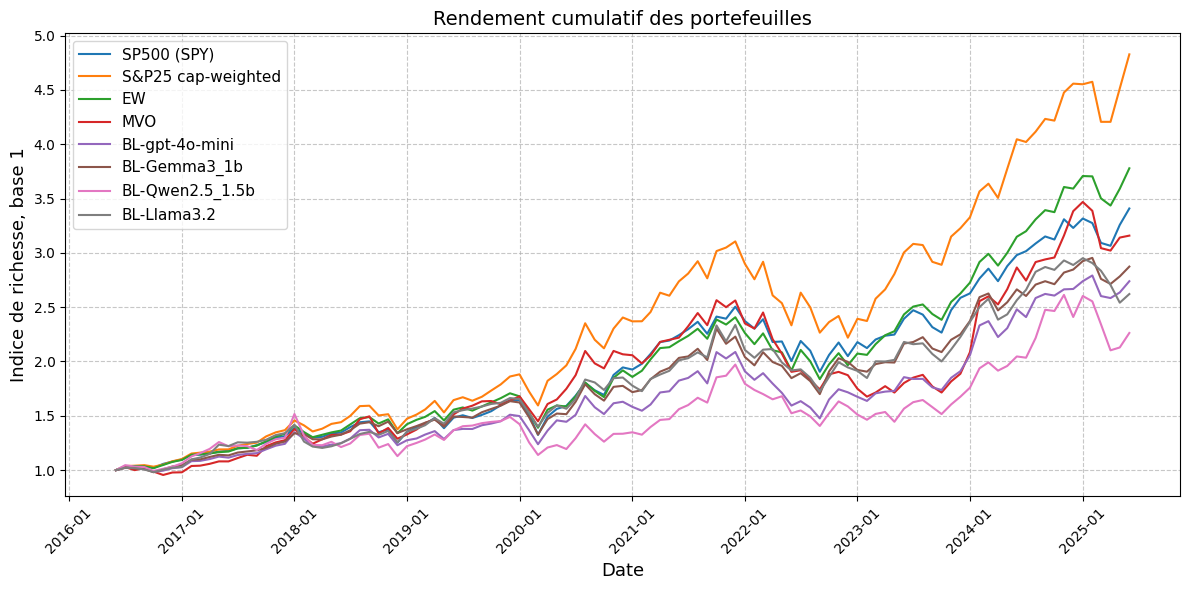

In [35]:
import matplotlib.pyplot as plt
import matplotlib

plt.figure(figsize=(12, 6))

for name, returns in portfolios.items():
    # S'assurer que toutes les séries sont comparées sur le même index mensuel
    ret = returns.reindex(common_idx).dropna().astype(float)

    # Indice de richesse : 1$ investi au début de la période
    wealth = (1 + ret).cumprod()

    # Ajouter un point initial à 1 avant le premier rendement réalisé
    first_date = wealth.index[0]

    # Comme les dates ont été standardisées au début du mois,
    # le capital initial est placé au début du mois précédent.
    if isinstance(first_date, pd.Timestamp):
        initial_date = first_date - pd.offsets.MonthBegin(1)
    else:
        initial_date = first_date - 1

    wealth = pd.concat([
        pd.Series([1.0], index=[initial_date]),
        wealth
    ])

    plt.plot(wealth.index, wealth.values, label=name)

plt.grid(True, linestyle="--", alpha=0.7)
plt.xlabel("Date", fontsize=13)
plt.ylabel("Indice de richesse, base 1", fontsize=13)
plt.title("Rendement cumulatif des portefeuilles", fontsize=14)
plt.legend(loc="upper left", fontsize=11)

plt.gca().xaxis.set_major_locator(matplotlib.dates.YearLocator())
# plt.gca().xaxis.set_major_locator(matplotlib.dates.MonthLocator(interval=1))
plt.gca().xaxis.set_major_formatter(matplotlib.dates.DateFormatter("%Y-%m"))
# plt.gca().xaxis.set_major_formatter(matplotlib.dates.DateFormatter("%Y-%m"))
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()


